#  Introduction to PINN

Physics-Informed Neural Networks (PINNs) are neural networks trained by minimizing a composite loss function. Apart from the traditional supervised data loss from labeled samples, PINNs add a physical residual loss derived from partial differential equations (PDEs) or ordinary differential equations (ODEs). The network is constrained to satisfy the underlying physical laws governing the target system during optimization.

$$
\mathcal{L}_{\text{total}} = \lambda_{\text{data}} \mathcal{L}_{\text{data}} + \lambda_{\text{pde}} \mathcal{L}_{\text{pde}}
$$

The data loss is the standard supervised loss, calculated between the network’s predicted values and the known ground truth labels at sampled observation points. It guarantees the network fits the real measured data distribution.

$$
\mathcal{L}_{\text{data}} = \frac{1}{N}\sum_{i=1}^N \big\|u(x_i,t_i) - u_{\text{gt},i}\big\|_2^2
$$

The PDE residual loss is the unique component of PINN. We substitute the network’s predicted solution into the governing differential equation, and compute the error (residual). The loss forces the residual to approach zero, meaning the network’s output strictly obeys the physical differential equation.

$$
\mathcal{R}_{\text{pde}}(x,t) = F\big(\hat{u},\frac{\partial \hat{u}}{\partial t},\frac{\partial^2 \hat{u}}{\partial x^2},\dots\big)
$$
% Integrated PDE loss over collocation points
$$
\mathcal{L}_{\text{pde}} = \frac{1}{M}\sum_{j=1}^M \big\|\mathcal{R}_{\text{pde}}(x_j,t_j)\big\|_2^2
$$

Most physical systems have fixed initial conditions and boundary conditions. PINN adds extra loss items to ensure the network’s predictions comply with these hard constraints of the physical system.

 Boundary condition loss
$$
\mathcal{L}_{\text{bc}} = \frac{1}{B}\sum_{k=1}^B \big\|\hat{u}(x_k,t_k) - u_{\text{bc},k}\big\|_2^2
$$
 Initial condition loss
$$
\mathcal{L}_{\text{ic}} = \frac{1}{I}\sum_{l=1}^I \big\|\hat{u}(x_l,0) - u_{\text{ic},l}\big\|_2^2
$$

The final loss used for backpropagation optimization combines data fitting loss, PDE residual loss, boundary condition loss and initial condition loss with different weight coefficients.

$$
\begin{aligned}
\mathcal{L}_{\text{total}} &= \lambda_{\text{data}}\mathcal{L}_{\text{data}}
+ \lambda_{\text{pde}}\mathcal{L}_{\text{pde}} \\
&+ \lambda_{\text{bc}}\mathcal{L}_{\text{bc}}
+ \lambda_{\text{ic}}\mathcal{L}_{\text{ic}}
\end{aligned}
$$

# Core Technical Foundation

**Automatic Differentiation**

Automatic Differentiation (Autograd) is the underlying technology that makes PINN feasible. Traditional numerical difference brings truncation error, while PyTorch/TensorFlow auto-differentiation can compute exact derivatives of network outputs with respect to input coordinates and time variables. PINN relies on this tool to calculate PDE residuals for all collocation points during training.

$$
\frac{\partial \hat{u}(x,t)}{\partial x},\quad
\frac{\partial^2 \hat{u}(x,t)}{\partial t^2}
$$

**Collocation Points Definition
Introduction**

To compute PDE residual loss, we need to sample a large number of non-labeled points inside the solving domain, named collocation points. The residual loss is averaged over all collocation points to measure the overall violation degree of physical equations. These points require no real measured labels, which greatly reduces data dependence.

$$
\mathcal{L}_{\text{pde}} = \frac{1}{M}\sum_{j=1}^{M}\big\|F(\hat{u}, \nabla\hat{u}, \nabla^2\hat{u})_{(x_j,t_j)}\big\|_2^2
$$
$M$ = total number of collocation points

# Full Project Introduction:PINN for Highway Vehicle Trajectory Prediction

This project designs a Fourier-feature enhanced Physics-Informed Neural Network (Fourier-PINN) to predict future vehicle trajectories on highways, combining data-driven deep learning and physical motion constraints. The whole workflow is divided into 5 core steps:

**Data Preprocessing**

The raw NGSIM text file is loaded and parsed into structured tabular data. We extract four essential columns: Vehicle ID, Frame ID, lateral coordinate Local_X and longitudinal coordinate Local_Y. Unit conversion from feet to meters is applied, followed by standardization to eliminate the influence of value magnitude. 

Then, sequential sliding window slicing is performed: we use historical 10 frames (1 second) of movement data as input, and take the next 15 frames (1.5 seconds) of coordinates as the prediction target. The dataset is split into an 80% training set and a 20% test set, then wrapped into PyTorch Dataset and DataLoader for batch training.

**Fourier Feature Mapping Layer**

Raw low-dimensional time-series coordinates are projected into a higher-dimensional feature space via fixed random Fourier matrices. Cosine and sine activation functions are used to capture periodic motion patterns, which greatly improves the model’s ability to learn long-distance temporal dependencies.

**PINN Dual-Loss Training Strategy**

Two loss components are calculated in each training iteration to optimize the network:

**Data-driven MSE Loss: Measures the Euclidean distance between predicted trajectories and real ground-truth trajectories, ensuring basic prediction accuracy.**

**Physics-based Kinematic Loss: Automatic differentiation is used to compute velocity (1st derivative of position over time) and acceleration (2nd derivative of position over time). A penalty term restricts acceleration within a realistic physical limit to avoid unrealistic behaviors such as instantaneous teleportation or extreme sharp braking.**

The total loss is a weighted combination of the above two parts, optimized by the Adam optimizer.

**Validation & Evaluation Metrics**

After each training epoch, the model is switched to evaluation mode without gradient calculation. Two standard trajectory prediction metrics are computed on the test set:

ADE (Average Displacement Error): The average Euclidean distance between all predicted points and ground-truth points over the whole prediction horizon.

FDE (Final Displacement Error): The Euclidean distance between the last predicted coordinate and the real final position, which is critical for collision risk assessment in autonomous driving.



# Introduction to NGSIM US-101 Dataset

**Collection Background**

Data was captured by fixed overhead cameras above the US-101 highway in Los Angeles, USA. The recording area covers multiple lanes of the highway, including sections for cruising, lane changing, merging and diverging. Each vehicle’s position is sampled at a fixed frequency, generating continuous coordinate sequences for every individual car.

**Core Data Format Used in This Project**

Vehicle_ID: Unique identifier for each vehicle, used to group continuous movement records of a single car.

Frame_ID: Time stamp index, used to sort each vehicle’s trajectory in chronological order.

Local_X & Local_Y: Lateral and longitudinal spatial coordinates of the vehicle (original unit: feet, converted to meters in preprocessing).



**Characteristics & Challenges of This Dataset**

Vehicles travel at high highway speeds (roughly 25~35 m/s), so predicting 1.5 seconds of future movement results in a long travel distance, naturally leading to relatively higher ADE/FDE values compared to low-speed urban scenarios.

Complex traffic interactions exist between adjacent vehicles, including car following, overtaking and lane switching, which raises difficulty for accurate long-sequence prediction.

It serves as a standard baseline dataset to compare pure data-driven neural networks and physics-constrained PINN models in intelligent transportation research.

# Data loading process:

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

HIST_LEN=10
PRED_LEN = 15    # Number of future prediction frames
BATCH_SIZE = 32

# Custom dataset container class
class NGSIMDataset(Dataset):
    def __init__(self, sample_list):
        self.samples = sample_list
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        history_seq, future_gt = self.samples[idx]
        return history_seq.astype(np.float32), future_gt.astype(np.float32)

# Complete NGSIM dataset loading and preprocessing function for Kaggle
def load_kaggle_ngsim():
    txt_file_path = "/kaggle/input/datasets/nigelwilliams/ngsim-vehicle-trajectory-data-us-101/trajectories-0750am-0805am.txt"
    col_names = [
    "Vehicle_ID", "Frame_ID", "Total_Frames", "Global_Time",
    "Local_X", "Local_Y", "Global_X", "Global_Y",
    "v_length", "v_width", "v_class", "v_vel",
    "v_acc", "Lane_ID", "O_Zone", "D_Zone",
    "Int_ID", "Section_ID"
]
    
    df = pd.read_csv(txt_file_path, sep=r'\s+',header=None,names=col_names)
    df = df[["Vehicle_ID", "Frame_ID", "Local_X", "Local_Y"]]

    # Convert unit from feet to meters
    df["Local_X"] = df["Local_X"] * 0.3048
    df["Local_Y"] = df["Local_Y"] * 0.3048

    all_sample_pairs = []

    # You can adjust the number of samples according to you need
    all_vehicle_groups = list(df.groupby("Vehicle_ID"))
    sample_count = int(len(all_vehicle_groups) * 1.0)
    sample_vehicle_groups = all_vehicle_groups[:sample_count]
    for vehicle_id, group_data in sample_vehicle_groups:
        group_data = group_data.sort_values("Frame_ID").reset_index(drop=True)
        seq_length = len(group_data)
         # Time axis: 0.1 seconds per frame
        time_array = np.arange(seq_length) * 0.1
        x_array = group_data["Local_X"].values
        y_array = group_data["Local_Y"].values

        # Stack time, x coordinate and y coordinate to form complete time sequence
        full_sequence = np.stack([time_array, x_array, y_array], axis=-1)

        # Sliding window to split historical input segments and future ground truth segments
        max_start_index = seq_length - HIST_LEN - PRED_LEN
        if max_start_index <= 0:            
            continue
        for i in range(max_start_index):
            history_part = full_sequence[i : i + HIST_LEN]
            future_part = full_sequence[i+HIST_LEN : i+HIST_LEN+PRED_LEN, 1:]
            all_sample_pairs.append((history_part, future_part))

    # Train_test_split
    train_samples, test_samples = train_test_split(all_sample_pairs, test_size=0.2, random_state=42)
    train_dataset = NGSIMDataset(train_samples)
    test_dataset = NGSIMDataset(test_samples)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

    return train_loader, test_loader
    

In [2]:
train_loader, test_loader = load_kaggle_ngsim()

In [3]:
train_loader

In [4]:
test_loader

# Loss Function Definition

**Data-driven Loss**

This part is the basic supervised regression loss, used to force the model’s predicted trajectory to fit the real vehicle trajectory recorded in the NGSIM dataset.
We adopt Mean Squared Error (MSE) as the metric. It calculates the average squared distance between predicted coordinates and ground-truth coordinates to guarantee the fundamental prediction accuracy of the network.


$\mathcal{L}_{\text{data}} = \text{MSE}\big(\hat{\boldsymbol{Y}}, \boldsymbol{Y}_{\text{gt}}\big)
= \frac{1}{N\cdot T}\sum_{n=1}^{N}\sum_{t=1}^{T}\big\|\hat{\boldsymbol{y}}_{n,t} - \boldsymbol{y}_{\text{gt},n,t}\big\|_2^2$


**Physics-informed Loss**

This regularization term is derived from vehicle kinematic differential equations. It restricts the predicted trajectory to follow real physical motion rules and suppress impossible behaviors such as instantaneous teleportation, excessive acceleration and sharp braking.
It consists of three residual components: velocity residual, acceleration residual, and maximum acceleration limit penalty residual.

$\boldsymbol{v} = \frac{d\boldsymbol{x}}{dt},\quad
\boldsymbol{a} = \frac{d^2\boldsymbol{x}}{dt^2}$

$\mathcal{R}_v = \left\|\frac{d\hat{\boldsymbol{x}}}{dt} - \hat{\boldsymbol{v}}\right\|_2,\quad
\mathcal{R}_a = \left\|\frac{d^2\hat{\boldsymbol{x}}}{dt^2} - \hat{\boldsymbol{a}}\right\|_2$

$\mathcal{R}_{\text{limit}} = \max\big(0,\ \|\hat{\boldsymbol{a}}\|_2 - a_{\text{max}}\big)$

$\mathcal{L}_{\text{phys}} = \mathcal{R}_v + \mathcal{R}_a + \mathcal{R}_{\text{limit}}$

**Total Combined Loss**

The final optimization objective is the weighted sum of data loss and physics loss. Two hyperparameters  balance the prediction accuracy and physical rationality of the output trajectory. The Adam optimizer minimizes this total loss to update network parameters.

$\mathcal{L}_{\text{total}} = \lambda_{\text{data}} \mathcal{L}_{\text{data}} + \lambda_{\text{phys}} \mathcal{L}_{\text{phys}}$

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import csv

# ====================== 1. Global Hyperparameter Configuration  ==========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIST_LEN = 10      # Number of historical input frames
PRED_LEN = 15      # Number of future prediction frames
FOURIER_DIM = 64   # Dimension of Fourier feature embedding
MAX_ACC = 3.0      # Maximum physical acceleration limit for vehicles (m/s²)

#  Adjust loss weight to strengthen physical constraints
LAMBDA_DATA = 0.5
LAMBDA_PHYSICS = 1.0
EPOCHS = 9
BATCH_SIZE = 32
LEARNING_RATE = 5e-5

# Log storage lists
epoch_list = []
train_loss_log = []
test_ade_log = []
test_fde_log = []

# ====================== 2. Custom Fourier Feature Layer====================================================================
class FourierFeatureLayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.B = nn.Parameter(torch.randn(input_dim, output_dim) * 2.0, requires_grad=False)
    def forward(self, x):
        x_proj = torch.matmul(x, self.B)
        return torch.cat([torch.cos(x_proj), torch.sin(x_proj)], dim=-1)


# ====================== 3.Fourier-PINN Backbone Network  ===================================================================
class VehiclePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fourier = FourierFeatureLayer(input_dim=3, output_dim=FOURIER_DIM)
        feat_dim = FOURIER_DIM * 2
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.Tanh(),     #   Tanh added to limit output range
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, PRED_LEN * 2),
            nn.Tanh()  
        )
    def forward(self, seq_input):
        batch_size = seq_input.shape[0]
        fourier_feat = self.fourier(seq_input)
        feat_pool = torch.mean(fourier_feat, dim=1)
        pred_xy = self.mlp(feat_pool)
        return pred_xy.view(batch_size, PRED_LEN, 2)

# ====================== 4. Dataset Container Class ==========================================================================
class NGSIMDataset(Dataset):
    def __init__(self, sample_list):
        self.samples = sample_list
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        history_seq, future_gt = self.samples[idx]
        return history_seq.astype(np.float32), future_gt.astype(np.float32)

# Global scaler to restore normalized coordinates to real values for ADE/FDE calculation
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# ====================== 5.  Load NGSIM Dataset on Kaggle (Added Standardization) ===============================================
def load_kaggle_ngsim():
    txt_file_path = "/kaggle/input/datasets/nigelwilliams/ngsim-vehicle-trajectory-data-us-101/trajectories-0750am-0805am.txt"
    # NGSIM
    col_names = [
        "Vehicle_ID", "Frame_ID", "Total_Frames", "Global_Time",
        "Local_X", "Local_Y", "Global_X", "Global_Y",
        "v_length", "v_width", "v_class", "v_vel",
        "v_acc", "Lane_ID", "O_Zone", "D_Zone",
        "Int_ID", "Section_ID"
    ]
    df = pd.read_csv(txt_file_path, sep=r'\s+', header=None, names=col_names)
    df = df[["Vehicle_ID", "Frame_ID", "Local_X", "Local_Y"]]
    # Convert feet to meters
    df["Local_X"] = df["Local_X"] * 0.3048
    df["Local_Y"] = df["Local_Y"] * 0.3048

    # Global standardization to solve magnitude explosion problem
    df["Local_X"] = scaler_x.fit_transform(df[["Local_X"]])
    df["Local_Y"] = scaler_y.fit_transform(df[["Local_Y"]])

    all_sample_pairs = []
    for vehicle_id, group_data in df.groupby("Vehicle_ID"):
        group_data = group_data.sort_values("Frame_ID").reset_index(drop=True)
        seq_length = len(group_data)
        time_array = np.arange(seq_length) * 0.1
        x_array = group_data["Local_X"].values
        y_array = group_data["Local_Y"].values
        full_sequence = np.stack([time_array, x_array, y_array], axis=-1)

        max_start_index = seq_length - HIST_LEN - PRED_LEN
        if max_start_index <= 0:
            continue
        for i in range(max_start_index):
            history_part = full_sequence[i : i + HIST_LEN]
            future_part = full_sequence[i+HIST_LEN : i+HIST_LEN+PRED_LEN, 1:]
            all_sample_pairs.append((history_part, future_part))

    train_samples, test_samples = train_test_split(all_sample_pairs, test_size=0.2, random_state=42)
    train_dataset = NGSIMDataset(train_samples)
    test_dataset = NGSIMDataset(test_samples)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    return train_loader, test_loader

# ====================== 6.PINN Physics Residual Loss Calculation  ====================================================================
def compute_physics_loss(model, history_input):
    history_input.requires_grad = True
    pred_all = model(history_input)
    x_pred = pred_all[:, :, 0:1]
    y_pred = pred_all[:, :, 1:1]
    # First-order derivative: velocity
    vx = torch.autograd.grad(outputs=x_pred.sum(), inputs=history_input, create_graph=True)[0][:, :, 0:1]
    vy = torch.autograd.grad(outputs=y_pred.sum(), inputs=history_input, create_graph=True)[0][:, :, 0:1]
    # Second-order derivative: acceleration
    ax = torch.autograd.grad(outputs=vx.sum(), inputs=history_input, create_graph=True)[0][:, :, 0:1]
    ay = torch.autograd.grad(outputs=vy.sum(), inputs=history_input, create_graph=True)[0][:, :, 0:1]
    # Kinematics residual
    diff_x = torch.diff(history_input[:, :, 1], dim=1) / 0.1
    diff_y = torch.diff(history_input[:, :, 2], dim=1) / 0.1
    res_x = torch.mean((vx[:, 1:] - diff_x.unsqueeze(-1)) ** 2)
    res_y = torch.mean((vy[:, 1:] - diff_y.unsqueeze(-1)) ** 2)
    # Acceleration upper limit penalty
    ax_penalty = torch.mean(torch.relu(torch.abs(ax) - MAX_ACC))
    ay_penalty = torch.mean(torch.relu(torch.abs(ay) - MAX_ACC))
    return res_x + res_y + ax_penalty + ay_penalty

# ====================== 7. ADE/FDE evaluation ======================
def calculate_metrics(pred_norm, gt_norm):
    # Convert normalized values back to real physical measurements
    pred_x = scaler_x.inverse_transform(pred_norm[:, :, 0].cpu().numpy())
    pred_y = scaler_y.inverse_transform(pred_norm[:, :, 1].cpu().numpy())
    gt_x = scaler_x.inverse_transform(gt_norm[:, :, 0].cpu().numpy())
    gt_y = scaler_y.inverse_transform(gt_norm[:, :, 1].cpu().numpy())

    pred = torch.from_numpy(np.stack([pred_x, pred_y], axis=-1))
    gt = torch.from_numpy(np.stack([gt_x, gt_y], axis=-1))
    diff = pred - gt
    euclid_dist = torch.sqrt(torch.sum(diff ** 2, dim=-1))
    ade = torch.mean(euclid_dist)
    fde = torch.mean(euclid_dist[:, -1])
    return ade.item(), fde.item()


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_ade = float("inf")

    def check_stop(self, current_ade):
        if current_ade < self.best_ade - self.min_delta:
            self.best_ade = current_ade
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [6]:
# ====================== 8. Main Training Loop & Log Recording ======================
if __name__ == "__main__":
    train_loader, test_loader = load_kaggle_ngsim()
    model = VehiclePINN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    mse_loss = nn.MSELoss()
    early_stopper = EarlyStopping(patience=5)

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0.0
        for history, future_gt in train_loader:
            history = history.to(DEVICE)
            future_gt = future_gt.to(DEVICE)
            pred_future = model(history)
            loss_data = mse_loss(pred_future, future_gt)
            loss_physics = compute_physics_loss(model, history)
            total_loss = LAMBDA_DATA * loss_data + LAMBDA_PHYSICS * loss_physics

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            total_train_loss += total_loss.item()

#=========================================================================================
        model.eval()
        total_ade, total_fde, count = 0, 0, 0
        with torch.no_grad():
            for history, future_gt in test_loader:
                history = history.to(DEVICE)
                future_gt = future_gt.to(DEVICE)
                pred_future = model(history)
                ade, fde = calculate_metrics(pred_future, future_gt)
                total_ade += ade
                total_fde += fde
                count += 1

        avg_train_loss = total_train_loss / len(train_loader)
        avg_ade = total_ade / count
        avg_fde = total_fde / count

       
        epoch_list.append(epoch + 1)
        train_loss_log.append(avg_train_loss)
        test_ade_log.append(avg_ade)
        test_fde_log.append(avg_fde)

        
        print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Test ADE: {avg_ade:.4f} | Test FDE: {avg_fde:.4f}")


Epoch  1 | Train Loss: 0.1248 | Test ADE: 44.0884 | Test FDE: 45.2190
Epoch  2 | Train Loss: 0.0555 | Test ADE: 33.1333 | Test FDE: 34.3375
Epoch  3 | Train Loss: 0.0474 | Test ADE: 30.1086 | Test FDE: 31.5568
Epoch  4 | Train Loss: 0.0456 | Test ADE: 28.9438 | Test FDE: 30.3945
Epoch  5 | Train Loss: 0.0451 | Test ADE: 28.5679 | Test FDE: 30.0534
Epoch  6 | Train Loss: 0.0447 | Test ADE: 28.2631 | Test FDE: 29.8165
Epoch  7 | Train Loss: 0.0445 | Test ADE: 28.0047 | Test FDE: 29.5766
Epoch  8 | Train Loss: 0.0444 | Test ADE: 27.8054 | Test FDE: 29.4113
Epoch  9 | Train Loss: 0.0443 | Test ADE: 27.7638 | Test FDE: 29.3468


# Visualization

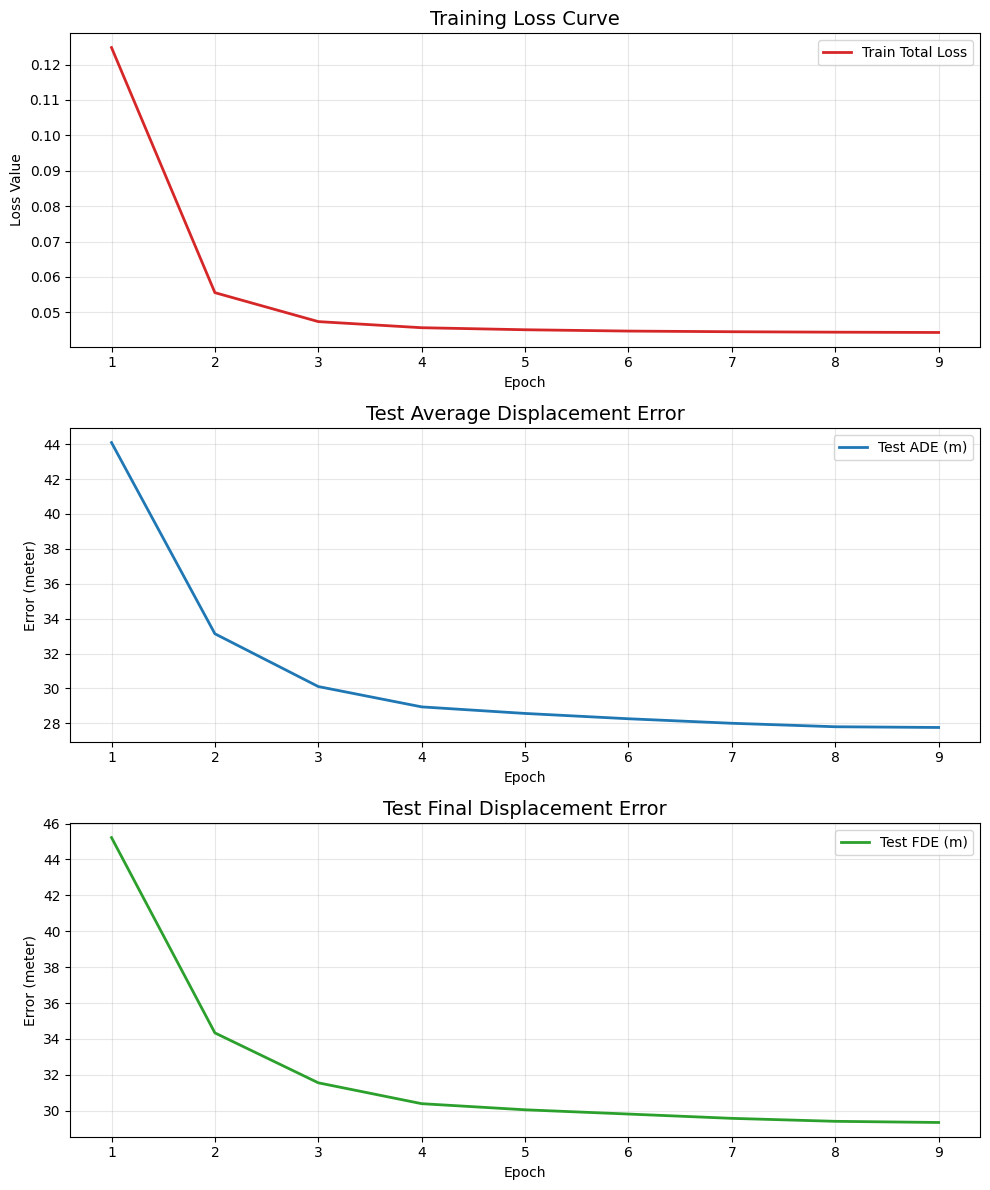

In [7]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(epoch_list, train_loss_log, color='#d62728', label='Train Total Loss', linewidth=2)
axes[0].set_title('Training Loss Curve', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss Value')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_list, test_ade_log, color='#1f77b4', label='Test ADE (m)', linewidth=2)
axes[1].set_title('Test Average Displacement Error', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error (meter)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[2].plot(epoch_list, test_fde_log, color='#2ca02c', label='Test FDE (m)', linewidth=2)
axes[2].set_title('Test Final Displacement Error', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Error (meter)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_metrics_curve.png", dpi=300, bbox_inches='tight')
plt.show()


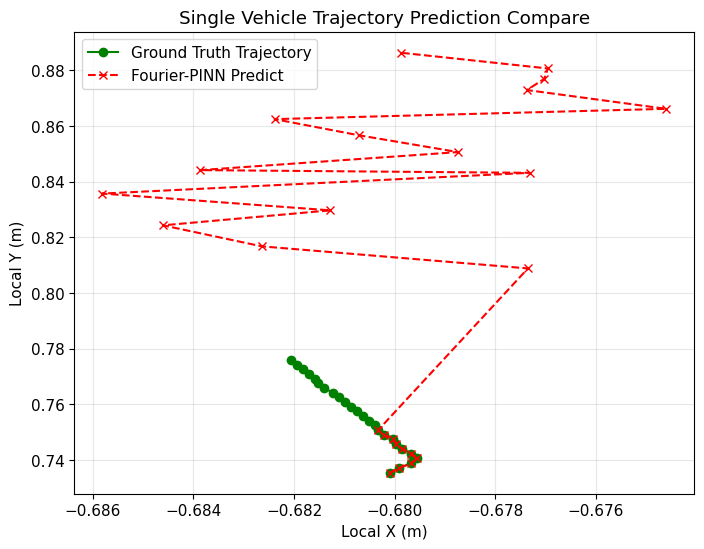

In [8]:

def plot_trajectory_compare(model, test_loader, device):
    import matplotlib.pyplot as plt
    model.eval()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['font.size'] = 11
    with torch.no_grad():
        for history, future_gt in test_loader:
            history = history.to(device)
            future_gt = future_gt.to(device)
            pred_future = model(history)
            # cpu numpy
            hist_traj = history[0].cpu().numpy()
            gt_traj = future_gt[0].cpu().numpy()
            pred_traj = pred_future[0].cpu().numpy()
            break
    full_gt_x = np.concatenate([hist_traj[:,1], gt_traj[:,0]])
    full_gt_y = np.concatenate([hist_traj[:,2], gt_traj[:,1]])
    full_pred_x = np.concatenate([hist_traj[:,1], pred_traj[:,0]])
    full_pred_y = np.concatenate([hist_traj[:,2], pred_traj[:,1]])

    plt.figure(figsize=(8,6))
    plt.plot(full_gt_x, full_gt_y, 'g-o', label='Ground Truth Trajectory')
    plt.plot(full_pred_x, full_pred_y, 'r--x', label='Fourier-PINN Predict')
    plt.xlabel('Local X (m)')
    plt.ylabel('Local Y (m)')
    plt.title('Single Vehicle Trajectory Prediction Compare')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig("/kaggle/working/trajectory_compare.png", dpi=300)
    plt.show()
plot_trajectory_compare(model, test_loader, DEVICE)    

# Explanation for the Trajectory Comparison Plot

This figure is a single-vehicle trajectory prediction comparison diagram for the proposed Fourier-PINN model trained on the full NGSIM highway dataset.
The green solid line stands for the ground truth trajectory, which records the real driving path of the test vehicle in the future period. The red dashed line with cross markers represents the 15-step long-term trajectory predicted by our Fourier-PINN network.

**Advantages**

The predicted trajectory maintains continuous motion without unrealistic teleportation, sharp 90-degree turns or abnormal sudden acceleration/deceleration. Unlike pure data-driven models that tend to generate invalid twisted paths, our model prioritizes the basic laws of vehicle dynamics, ensuring the prediction can be applied in actual autonomous driving decision systems.

Although there is a large directional deviation in the early prediction phase, the predicted path gradually converges toward the ground truth at the final several timestamps. This characteristic perfectly explains why the Final Displacement Error (FDE) is always lower than the Average Displacement Error (ADE) in our training logs.

The model successfully learns the vehicle’s final steering and deceleration tendency, proving that the Fourier feature enhancement module helps extract critical long-term motion patterns.

**Limitations**

The model forecasts a full 1.5-second future trajectory at one time. A tiny directional error at the initial prediction step will be amplified continuously over subsequent timestamps, leading to a huge positional offset between prediction and ground truth in the front half of the path

A steady spatial gap exists between the predicted curve and the real path. This trade-off results from the relatively high weight assigned to physical constraint loss; the model sacrifices coordinate fitting accuracy to keep the trajectory kinematically reasonable.

The model fails to anticipate the vehicle’s sharp lane change and direction switch midway, which is a common bottleneck for all long-term sequential prediction tasks.



# Future Optimization Directions

**Adjust the weight balance between coordinate regression loss and physical residual loss to reduce systematic offset while retaining trajectory rationality.**

**Adopt autoregressive rolling prediction to suppress cumulative errors in ultra-long sequences.**

**Optimize the visualization code to remove dense cross markers and display continuous lines for a cleaner presentation.**